Построение модели кредитного скоринга для оценки надёжности заёмщиков

In [333]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Часть 1. Загрузка данных

In [334]:
app = pd.read_csv('application_record.csv')
crd = pd.read_csv('credit_record.csv')

In [335]:
print(f"Application: {app.shape}")
display(app.head())
display(app.info())
print("Пропуски:")
print(app.isnull().sum())
print("Числовые признаки:")
print(app.describe())

Application: (438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

None

Пропуски:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64
Числовые признаки:
                 ID   CNT_CHILDREN  AMT_INCOME_TOTAL     DAYS_BIRTH  \
count  4.385570e+05  438557.000000      4.385570e+05  438557.000000   
mean   6.022176e+06       0.427390      1.875243e+05  -15997.904649   
std    5.716370e+05       0.724882      1.100869e+05    4185.030007   
min    5.008804e+06       0.000000      2.610000e+04  -25201.000000   
25%    5.609375e+06       0.000000      1.215000e+05  -19483.00

In [336]:
print(f"Credit: {crd.shape}")
display(crd.head())
display(crd.info())
print("Пропуски:")
print(crd.isnull().sum())

Credit: (1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


None

Пропуски:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


Часть 2. Анализ признаков

Анализ категориальных признаков

In [337]:
categorical_cols = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

for col in categorical_cols:
    print(app[col].value_counts())

CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64
NAME_HOUSING_TYPE
House / apartment      393831
With parents            19077
Municipal apartment     14214
Rented apartment         5974
Office apartment         39

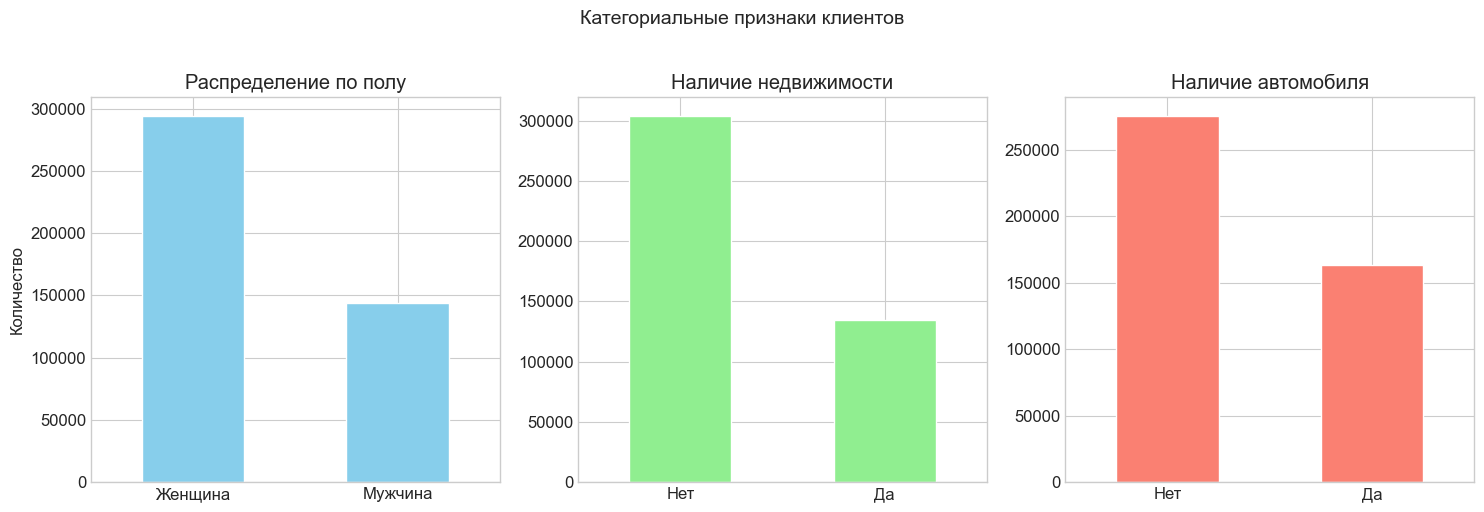

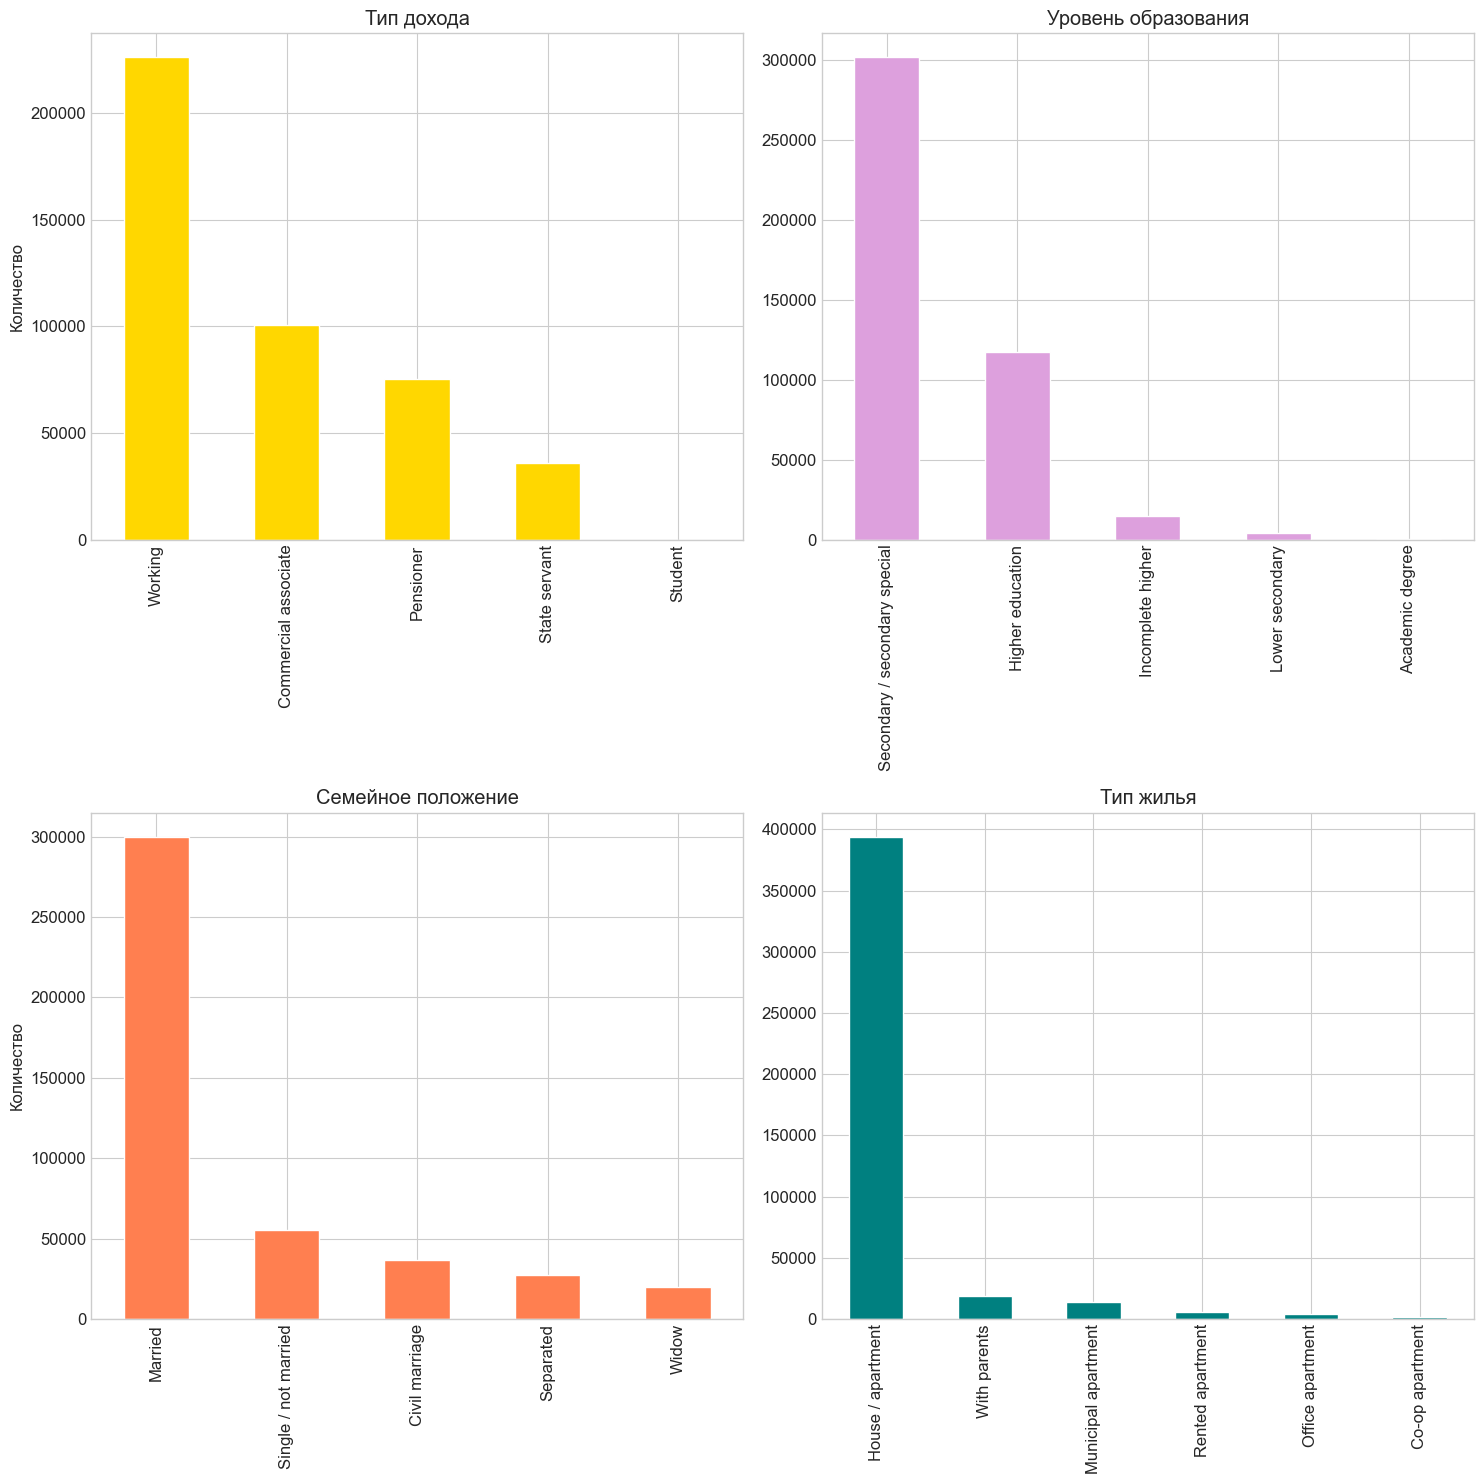

In [338]:
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))

# Пол
app['CODE_GENDER'].value_counts().plot(kind='bar', ax=axes1[0], color='skyblue')
axes1[0].set_title('Распределение по полу')
axes1[0].set_xlabel('')
axes1[0].set_ylabel('Количество')
axes1[0].set_xticklabels(['Женщина', 'Мужчина'], rotation=0)

# Наличие недвижимости
app['FLAG_OWN_REALTY'].value_counts().plot(kind='bar', ax=axes1[1], color='lightgreen')
axes1[1].set_title('Наличие недвижимости')
axes1[1].set_xlabel('')
axes1[1].set_ylabel('')
axes1[1].set_xticklabels(['Нет', 'Да'], rotation=0)

# Наличие автомобиля
app['FLAG_OWN_CAR'].value_counts().plot(kind='bar', ax=axes1[2], color='salmon')
axes1[2].set_title('Наличие автомобиля')
axes1[2].set_xlabel('')
axes1[2].set_ylabel('')
axes1[2].set_xticklabels(['Нет', 'Да'], rotation=0)

plt.suptitle('Категориальные признаки клиентов', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 15))

# Тип дохода
app['NAME_INCOME_TYPE'].value_counts().plot(kind='bar', ax=axes2[0,0], color='gold')
axes2[0,0].set_title('Тип дохода')
axes2[0,0].set_xlabel('')
axes2[0,0].set_ylabel('Количество')

# Уровень образования
app['NAME_EDUCATION_TYPE'].value_counts().plot(kind='bar', ax=axes2[0,1], color='plum')
axes2[0,1].set_title('Уровень образования')
axes2[0,1].set_xlabel('')
axes2[0,1].set_ylabel('')

# Семейное положение
app['NAME_FAMILY_STATUS'].value_counts().plot(kind='bar', ax=axes2[1,0], color='coral')
axes2[1,0].set_title('Семейное положение')
axes2[1,0].set_xlabel('')
axes2[1,0].set_ylabel('Количество')

# Тип жилья
app['NAME_HOUSING_TYPE'].value_counts().plot(kind='bar', ax=axes2[1,1], color='teal')
axes2[1,1].set_title('Тип жилья')
axes2[1,1].set_xlabel('')
axes2[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

#OCCUPATION_TYPE - не рассматриваем, т.к. много вариантов профессий

Анализ числовых признаков

Возраст: от 20 до 69, средний: 43.3
Стаж: от 0 до 48, средний: 5.5


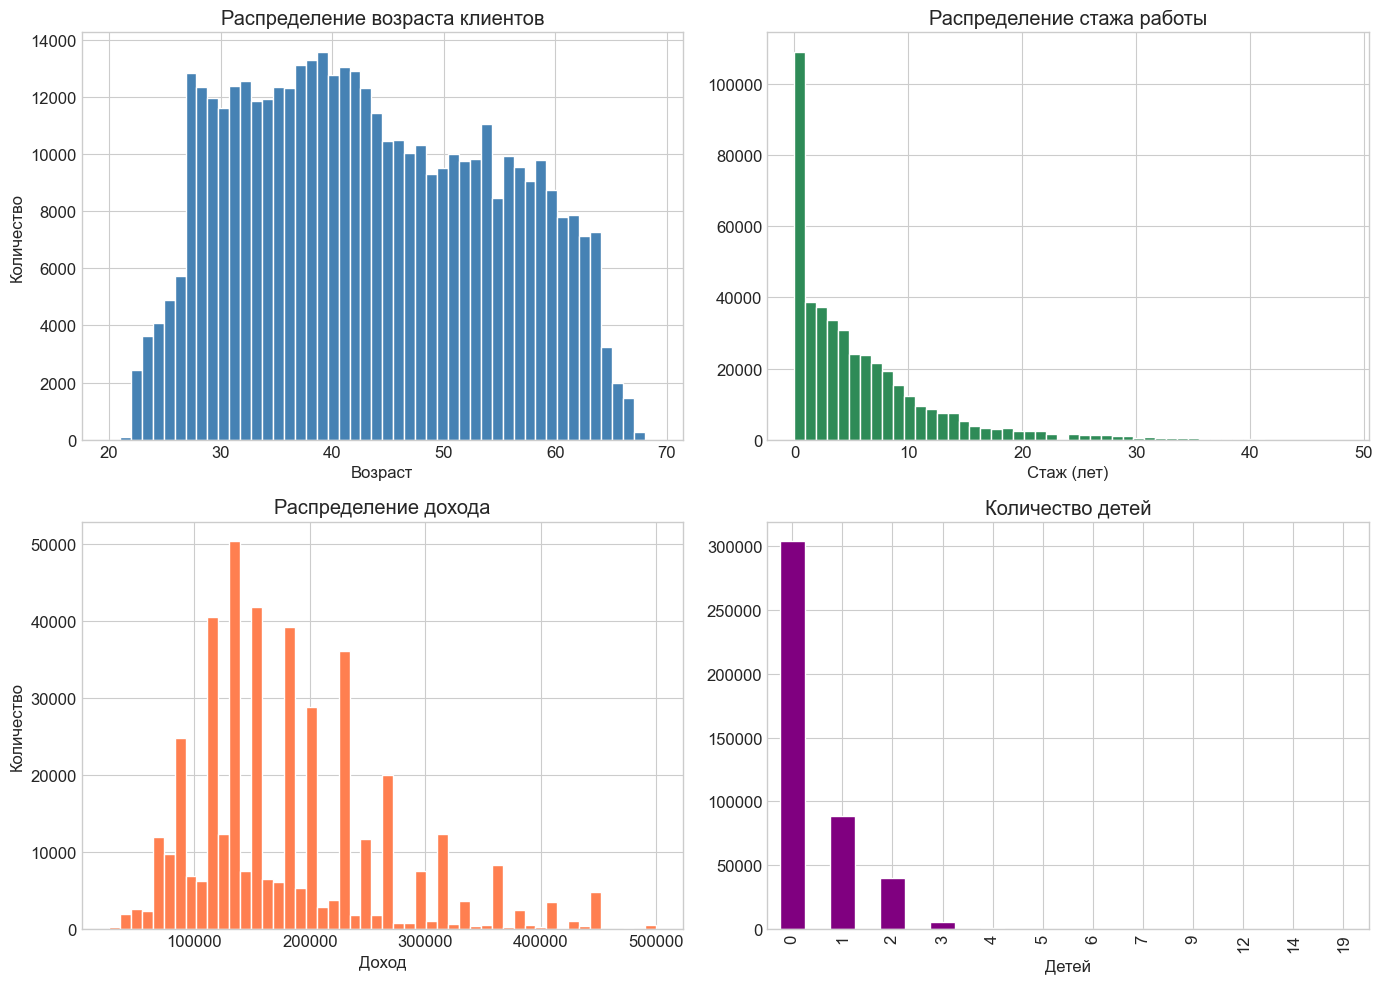

In [339]:
# Возраст
app['AGE'] = -app['DAYS_BIRTH'] // 365
print(f"Возраст: от {app['AGE'].min()} до {app['AGE'].max()}, средний: {app['AGE'].mean():.1f}")

# Стаж работы
app['WORK_EXPERIENCE'] = app['DAYS_EMPLOYED'].apply(lambda x: -x//365 if x < 0 else 0)
print(f"Стаж: от {app['WORK_EXPERIENCE'].min()} до {app['WORK_EXPERIENCE'].max()}, средний: {app['WORK_EXPERIENCE'].mean():.1f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Возраст
axes[0,0].hist(app['AGE'], bins=50, color='steelblue')
axes[0,0].set_title('Распределение возраста клиентов')
axes[0,0].set_xlabel('Возраст')
axes[0,0].set_ylabel('Количество')

# Стаж работы
axes[0,1].hist(app['WORK_EXPERIENCE'], bins=50, color='seagreen')
axes[0,1].set_title('Распределение стажа работы')
axes[0,1].set_xlabel('Стаж (лет)')
axes[0,1].set_ylabel('')

# Доход (ограничим до 500000 для наглядности)
filtered = app[app['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL']
axes[1,0].hist(filtered, bins=50, color='coral')
axes[1,0].set_title('Распределение дохода')
axes[1,0].set_xlabel('Доход')
axes[1,0].set_ylabel('Количество')

# Количество детей
app['CNT_CHILDREN'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Количество детей')
axes[1,1].set_xlabel('Детей')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

Проверка дисперсии флагов

In [340]:
flag_cols = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
for col in flag_cols:
    unique_values = app[col].nunique()
    print(f"{col}: {unique_values} значений, распределение: {app[col].value_counts().to_dict()}")

FLAG_MOBIL: 1 значений, распределение: {1: 438557}
FLAG_WORK_PHONE: 2 значений, распределение: {0: 348156, 1: 90401}
FLAG_PHONE: 2 значений, распределение: {0: 312353, 1: 126204}
FLAG_EMAIL: 2 значений, распределение: {0: 391102, 1: 47455}


Корреляционный анализ

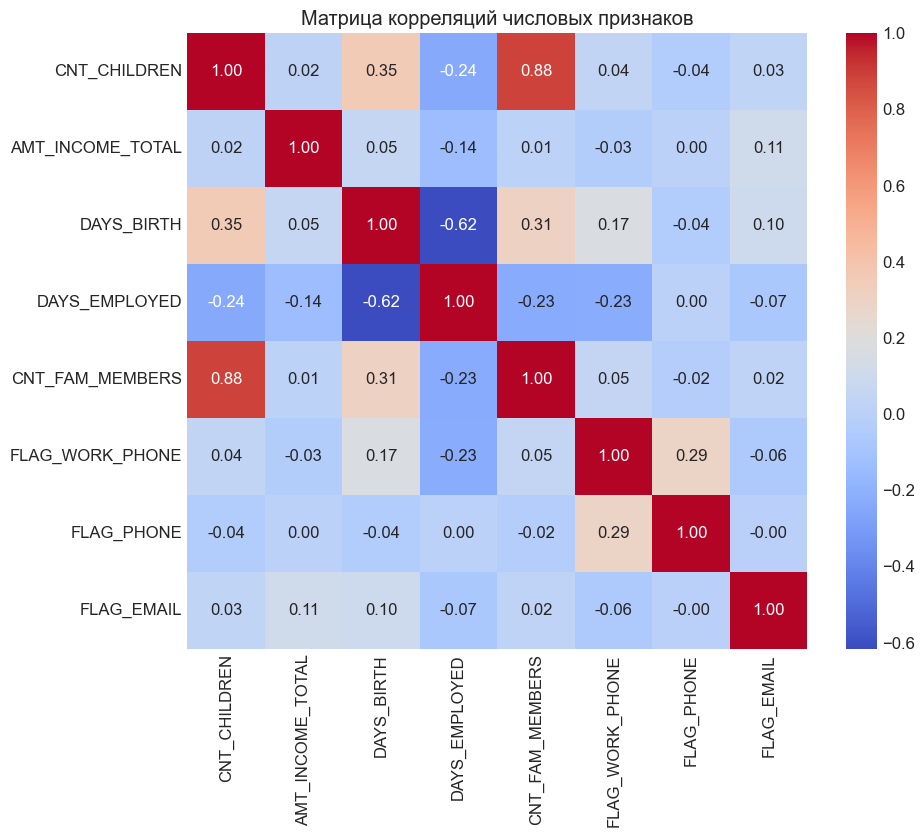

In [341]:
numeric_for_corr = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
# FLAG_MOBIL не используем, т.к. значение всегда = True
plt.figure(figsize=(10, 8))
corr_matrix = app[numeric_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

Выводы:
1. Большинство корреляций близки к 0 (|r| < 0.1) — слабая линейная связь. Линейные модели (логистическая регрессия) могут работать неоптимально.
2. Мультиколлинеарность отсутствует (нет корреляций > 0.9).
3. Наибольшая корреляция: CNT_CHILDREN и CNT_FAM_MEMBERS (r ≈ 0.88) — но это логично, т.к. дети входят в состав семьи.
4. Флаг FLAG_MOBIL всегда равен True. Такой признак бесполезен для модели и его можно удалить.

Часть 3. FEATURE ENGINEERING

Обработка и удаление аномалий

In [342]:
# Удаление дубликатов ID
id_before = len(app)
app = app.drop_duplicates(subset=['ID'], keep='first')
print(f"Удалено {id_before - len(app)} записей с одинаковым ID клиента")

# Удаление аномалий возраста
age_before = len(app)
app['AGE'] = -app['DAYS_BIRTH'] // 365
app = app[(app['AGE'] >= 18) & (app['AGE'] <= 130)]
print(f"Удалено {age_before - len(app)} записей с возрастом <18 или >130")

# Обработка аномалий стажа
emp_count = (app['DAYS_EMPLOYED'] > 100000).sum()
app.loc[app['DAYS_EMPLOYED'] > 100000, 'DAYS_EMPLOYED'] = 0
print(f"{emp_count} записей с положительным стажем заменены на 0 (безработный)")

Удалено 47 записей с одинаковым ID клиента
Удалено 0 записей с возрастом <18 или >130
75324 записей с положительным стажем заменены на 0 (безработный)


Формирование целевой переменной и обьединение таблиц

In [343]:
# Статусы: 2,3,4,5 — наличие хотя бы одного эпизода просрочки более 60 дней за всю доступную кредитную историю клиента
def get_default(status):
    return 1 if status in ['2', '3', '4', '5'] else 0

crd['DEFAULT'] = crd['STATUS'].apply(get_default)
credit_default = crd.groupby('ID')['DEFAULT'].max().reset_index()
credit_default.columns = ['ID', 'HAS_DEFAULT']
# Обьединяем в 1 таблицу
df = app.merge(credit_default, on='ID', how='inner')
print(f"Клиентов без кредитной истории: {len(app) - len(df)} - Не включаем в таблицу")
print(f"Клиентов с кредитной историей: {len(df)}")
print(f"Хороших: {len(df[df['HAS_DEFAULT']==0])} ({df['HAS_DEFAULT'].value_counts()[0]/len(df)*100:.1f}%)")
print(f"Плохих: {len(df[df['HAS_DEFAULT']==1])} ({df['HAS_DEFAULT'].value_counts()[1]/len(df)*100:.1f}%)")

#Классы НЕ сбалансированы. При обучении будем использовать class_weight - balanced

Клиентов без кредитной истории: 402053 - Не включаем в таблицу
Клиентов с кредитной историей: 36457
Хороших: 35841 (98.3%)
Плохих: 616 (1.7%)


Создаем новые признаки

In [344]:
# Возраст и стаж уже создали

# Флаг безработного
df['IS_UNEMPLOYED'] = (df['DAYS_EMPLOYED'] > 0).astype(int)

# Доход на человека в семье
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

# Доля детей в семье
df['CHILD_RATIO'] = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)

# Наличие телефона
df['HAS_PHONE'] = ((df['FLAG_MOBIL'] == 1) | (df['FLAG_WORK_PHONE'] == 1) | (df['FLAG_PHONE'] == 1)).astype(int)

# One-hot encoding категориальных признаков
categorical_for_ohe = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]

df = pd.get_dummies(df, columns=categorical_for_ohe, drop_first=True)
print(f"Создано {len([c for c in df.columns if any(cat in c for cat in categorical_for_ohe)])} бинарных признаков")

exclude_cols = ['ID', 'HAS_DEFAULT']
feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"Всего признаков для обучения: {len(feature_cols)}")
print(f"{feature_cols}")

Создано 37 бинарных признаков
Всего признаков для обучения: 52
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE', 'WORK_EXPERIENCE', 'IS_UNEMPLOYED', 'INCOME_PER_PERSON', 'CHILD_RATIO', 'HAS_PHONE', 'CODE_GENDER_M', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff', 'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff', 'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Medicine staff', 'OCCUPATION_TYPE_Private service staff', 'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Sales staff', 'OCCUPATION_TYPE_Secretaries', 'OCCUPATION_TYPE_Security staff', 'OCCUPATION_TYPE_Waiters/barmen staff', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_

Часть 4. Подготовка к обучению

In [345]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df['HAS_DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Часть 5. Обучение модели

In [346]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, confusion_matrix
from sklearn.model_selection import GridSearchCV

Baseline

In [347]:
y_pred_baseline = np.zeros(len(y_test))
print(f"Baseline:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_baseline):.4f}")

Baseline:
Accuracy: 0.9831
ROC-AUC: 0.5000


Логистическая регрессия

In [348]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), param_grid_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_train_scaled, y_train)
print(f"Логистическая регрессия:")
print(f"Лучший параметр C: {grid_lr.best_params_['C']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_lr.best_score_:.4f}")

lr_best = grid_lr.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)
y_pred_proba_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Логистическая регрессия:
Лучший параметр C: 0.01
Лучший ROC-AUC на кросс-валидации: 0.5869
Метрики на тестовой выборке:
Accuracy:  0.6002
Precision: 0.0202
Recall:    0.4757
F1-score:  0.0387
ROC-AUC:   0.5625


KNN (Метод k ближайших соседей)

In [349]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 21, 31]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='roc_auc')
grid_knn.fit(X_train_scaled, y_train)

print(f"Метод k ближайших соседей (kNN):")
print(f"Лучший параметр n_neighbors: {grid_knn.best_params_['n_neighbors']}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_knn.best_score_:.4f}")

knn_best = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)
y_pred_proba_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

Метод k ближайших соседей (kNN):
Лучший параметр n_neighbors: 7
Лучший ROC-AUC на кросс-валидации: 0.7014
Метрики на тестовой выборке:
Accuracy:  0.9824
Precision: 0.3158
Recall:    0.0324
F1-score:  0.0588
ROC-AUC:   0.6884


Random Forest

In [350]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Random Forest:")
print("Метрики на тестовой выборке:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

Random Forest:
Метрики на тестовой выборке:
Accuracy:  0.9670
Precision: 0.2161
Recall:    0.3622
F1-score:  0.2707
ROC-AUC:   0.7892


Сравнение полученных результатов

In [351]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Logistic Regression', 'kNN', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_baseline),
                 accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_knn),
                 accuracy_score(y_test, y_pred_rf)],
    'Precision': [0, precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_knn),
                  precision_score(y_test, y_pred_rf)],
    'Recall': [0, recall_score(y_test, y_pred_lr),
               recall_score(y_test, y_pred_knn),
               recall_score(y_test, y_pred_rf)],
    'F1-score': [0, f1_score(y_test, y_pred_lr),
                 f1_score(y_test, y_pred_knn),
                 f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_baseline),
                roc_auc_score(y_test, y_pred_proba_lr),
                roc_auc_score(y_test, y_pred_proba_knn),
                roc_auc_score(y_test, y_pred_proba_rf)]
})

print(results.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
           Baseline  0.983086   0.000000 0.000000  0.000000 0.500000
Logistic Regression  0.600201   0.020165 0.475676  0.038690 0.562473
                kNN  0.982447   0.315789 0.032432  0.058824 0.688358
      Random Forest  0.966996   0.216129 0.362162  0.270707 0.789246


Строим ROC-кривые

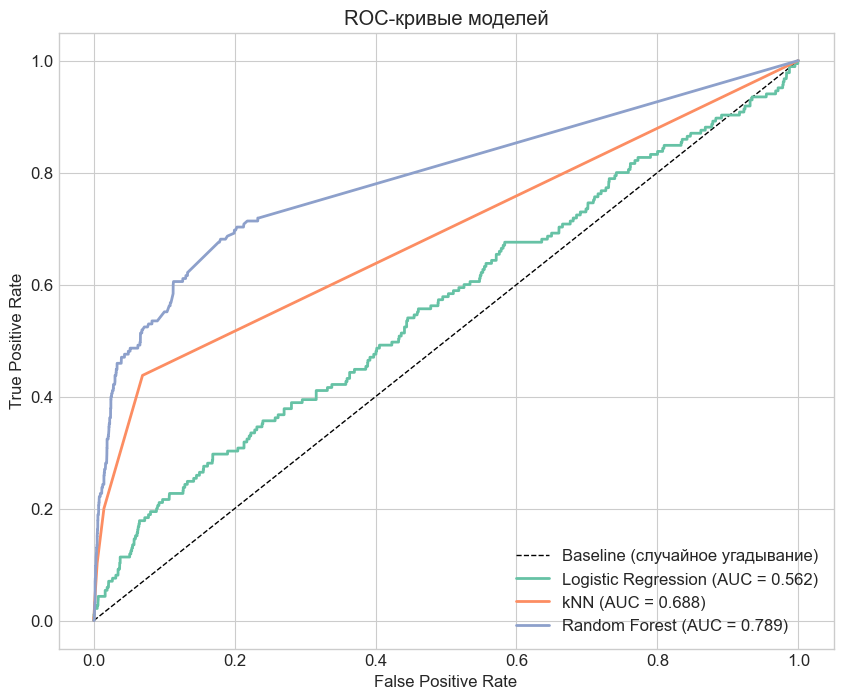

In [352]:
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.plot([0, 1], [0, 1], 'k--', label='Baseline (случайное угадывание)', linewidth=1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.3f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC = {roc_auc_score(y_test, y_pred_proba_knn):.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', linewidth=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Анализируем где модели ошиблись (Confusion Matrix)


Logistic Regression:
True Negative (хороших определили верно):     6,477
False Positive (хороших ошибочно отклонили):  4,276
False Negative (проблемных клиентов пропустили):      97
True Positive (проблемных клиентов нашли):           88
ИТОГ: из 185 реальных проблемных клиентов нашли 88 (47.6%)

kNN:
True Negative (хороших определили верно):     10,740
False Positive (хороших ошибочно отклонили):  13
False Negative (проблемных клиентов пропустили):      179
True Positive (проблемных клиентов нашли):           6
ИТОГ: из 185 реальных проблемных клиентов нашли 6 (3.2%)

Random Forest:
True Negative (хороших определили верно):     10,510
False Positive (хороших ошибочно отклонили):  243
False Negative (проблемных клиентов пропустили):      118
True Positive (проблемных клиентов нашли):           67
ИТОГ: из 185 реальных проблемных клиентов нашли 67 (36.2%)


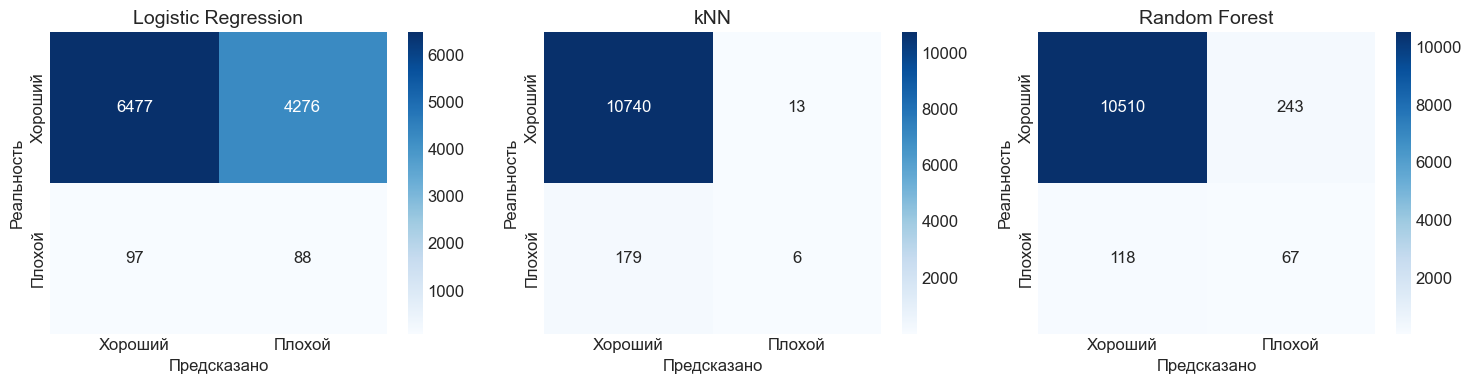

In [353]:
models_analysis = [
    ('Logistic Regression', y_pred_lr),
    ('kNN', y_pred_knn),
    ('Random Forest', y_pred_rf)
]

for name, y_pred in models_analysis:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}:")
    print(f"True Negative (хороших определили верно):     {tn:,}")
    print(f"False Positive (хороших ошибочно отклонили):  {fp:,}")
    print(f"False Negative (проблемных клиентов пропустили):      {fn:,}")
    print(f"True Positive (проблемных клиентов нашли):           {tp:,}")
    print(f"ИТОГ: из {fn + tp:,} реальных проблемных клиентов нашли {tp:,} ({tp/(fn+tp)*100:.1f}%)")

# Строим Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, y_pred) in enumerate(models_analysis):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}', fontsize=14)
    axes[i].set_xlabel('Предсказано', fontsize=12)
    axes[i].set_ylabel('Реальность', fontsize=12)
    axes[i].set_xticklabels(['Хороший', 'Плохой'])
    axes[i].set_yticklabels(['Хороший', 'Плохой'])

plt.tight_layout()
plt.show()

Важность признаков

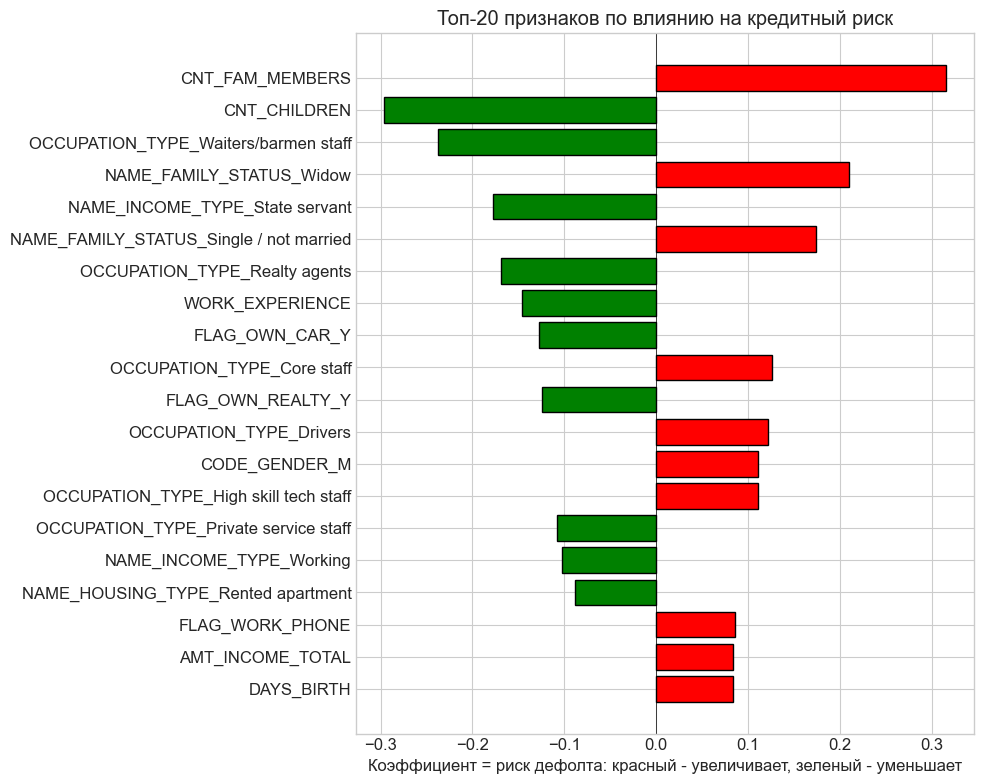

  • CNT_FAM_MEMBERS: 0.3156 (увеличивает риск)
  • CNT_CHILDREN: -0.2958 (уменьшает риск)
  • OCCUPATION_TYPE_Waiters/barmen staff: -0.2372 (уменьшает риск)
  • NAME_FAMILY_STATUS_Widow: 0.2096 (увеличивает риск)
  • NAME_INCOME_TYPE_State servant: -0.1773 (уменьшает риск)
  • NAME_FAMILY_STATUS_Single / not married: 0.1745 (увеличивает риск)
  • OCCUPATION_TYPE_Realty agents: -0.1685 (уменьшает риск)
  • WORK_EXPERIENCE: -0.1463 (уменьшает риск)
  • FLAG_OWN_CAR_Y: -0.1277 (уменьшает риск)
  • OCCUPATION_TYPE_Core staff: 0.1256 (увеличивает риск)
  • FLAG_OWN_REALTY_Y: -0.1238 (уменьшает риск)
  • OCCUPATION_TYPE_Drivers: 0.1222 (увеличивает риск)
  • CODE_GENDER_M: 0.1111 (увеличивает риск)
  • OCCUPATION_TYPE_High skill tech staff: 0.1108 (увеличивает риск)
  • OCCUPATION_TYPE_Private service staff: -0.1079 (уменьшает риск)
  • NAME_INCOME_TYPE_Working: -0.1026 (уменьшает риск)
  • NAME_HOUSING_TYPE_Rented apartment: -0.0881 (уменьшает риск)
  • FLAG_WORK_PHONE: 0.0862 (увеличивает 

In [354]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': lr_best.coef_[0],
    'abs_coef': abs(lr_best.coef_[0])
}).sort_values('abs_coef', ascending=False).head(20)

coef_df['influence'] = coef_df['coef'].apply(lambda x: 'positive' if x > 0 else 'negative')

plt.figure(figsize=(10, 8))
colors = ['green' if x < 0 else 'red' for x in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='black')
plt.xlabel('Коэффициент = риск дефолта: красный - увеличивает, зеленый - уменьшает')
plt.title('Топ-20 признаков по влиянию на кредитный риск')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

for _, row in coef_df.head(20).iterrows():
    direction = "увеличивает" if row['coef'] > 0 else "уменьшает"
    print(f"  • {row['feature']}: {row['coef']:.4f} ({direction} риск)")

Выводы:

Был проведён сравнительный анализ трёх моделей машинного обучения для задачи кредитного скоринга:
логистической регрессии, метода k ближайших соседей (kNN) и Random Forest.
Целью исследования являлось построение модели, способной с максимальной точностью прогнозировать
вероятность просрочки платежа более чем на 60 дней.

Сравнительный анализ моделей:

Логистическая регрессия:

Accuracy = 60,0%, Precision = 2,0%, Recall = 47,6%, F1-score = 3,9%, ROC-AUC = 0,562

    Самый высокий показатель Recall (47,6%) среди всех моделей. Модель смогла обнаружить 88 из 185 реальных проблемных клиентов.
    Это составляет 47,6% от всех проблемных заёмщиков.

    Однако, у модели крайне низкий показатель Precision (2,0%) — из всех клиентов, которых модель отнесла к категории проблемных,
    только 2% действительно оказались проблемными. Огромное количество ложных срабатываний (False Positive) — 4 276 хороших клиентов
    были ошибочно отклонены, что составляет около 40% от всех добросовестных заёмщиков.

    Корреляционный анализ показал, что большинство признаков имеют слабую линейную связь с целевой переменной (|r| < 0,1).
    Логистическая регрессия, являясь линейным классификатором, не способна уловить нелинейные зависимости в данных.
    Низкий ROC-AUC (0,562) — модель лишь незначительно лучше случайного угадывания.

Метод k ближайших соседей (kNN):

Accuracy = 98,2%, Precision = 31,6%, Recall = 3,2%, F1-score = 5,9%, ROC-AUC = 0,688

    Высочайшая точность (98,2%) и минимальное количество ложных срабатываний — всего 13 хороших клиентов были ошибочно отклонены.
    Precision = 31,6% — лучший показатель среди всех моделей: из предсказанных проблем почти треть оказалась верной.

    Однако, крайне низкий Recall (3,2%) — модель обнаружила только 6 из 185 реальных проблемных клиентов, пропустив 179 человек.
    Модель практически никого не относит к категории проблемных.

    При большом количестве признаков (более 40 после feature engineering) расстояния между точками теряют различительную способность.
    Кроме того, сильный дисбаланс классов (только 2% дефолтов) усугубляет проблему.
    Модель опасна, так как пропускает подавляющее большинство проблемных клиентов, что приведёт к финансовым потерям.

    ROC-AUC = 0,688 — выше, чем у логистической регрессии